# Analysis
In this notebook, all of the steps from the prior notebooks are applied to all events under scrutiny. The script 'analysis_execution.py' is used to loop over all events that were part of the selection.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import xarray as xr

## Subsetting ESDC
This has to be done to access ESDC locally. **Can be skipped** if already written to disk or available on cluster.

In [ ]:
# Import ESDL dataset
url = 'https://data.rsc4earth.de/download/EarthSystemDataCube/v3.0.1/esdc-8d-0.25deg-1x720x1440-3.0.1.zarr/'
ds_esdc = xr.open_zarr(url)

# Select only the variables you need
variables = ['kndvi', 'air_temperature_2m', 'min_air_temperature_2m', 
            'max_air_temperature_2m', 'precipitation_era5', 
            'root_moisture', 'evaporation', 'potential_evaporation']

ds_esdc = ds_esdc[variables]

# Restrict to the time period of interest (2000–2021)
ds_esdc = ds_esdc.sel(time=slice("2000-01-01", "2021-12-31"))

# Save to local Zarr store (folder on disk)
output_path = "data/esdc_subset.zarr" 
ds_esdc.to_zarr(output_path, mode="w")

## Run computations

In [ ]:
%run analysis_execution.py

21 events were skipped because the land masking resulted in an empty mask, i.e. no data over land available.

## Visualize Results


In [ ]:
# Load pre-computed results
df_all = pd.read_csv('21_08.csv', index_col=['event_label', 'veg_class'])

# Load translation df
df_translation = pd.read_csv('data/GLDA_veg_legend.csv', index_col=0)

In [4]:
df_all

n_days        t2m     t2mmin     t2mmax  \
event_label veg_class                                               
83007       1.0         9.439828  16.274485   7.013991  25.916573   
            5.0        17.539571  19.237293  10.049909  28.247648   
            7.0         6.909091  25.568640  16.587254  34.162804   
            10.0       14.817383  26.356934  16.850323  35.251453   
            12.0       18.372679  23.235512  14.478889  31.925268   
...                          ...        ...        ...        ...   
103567      12.0        6.000000  25.139286  22.405426  28.939657   
81632       2.0        18.000000  15.296368   9.923286  21.340736   
79098       7.0        12.000000  13.642197   8.687145  19.107574   
121988      2.0         8.000000  20.744495  18.467050  23.423620   
95429       2.0         3.500000  19.885818  15.589580  24.966448   

                               prec    soil_moist          evap  \
event_label veg_class                                             
83007       1.0        10602.775926   3164.083820  18448.079859   
            5.0        30377.167129  15596.574674  45392.423625   
            7.0          827.169258    728.964044    977.092309   
            10.0       11437.120630  11167.170488  13110.908704   
            12.0       66851.934986  48426.106051  80650.313893   
...                             ...           ...           ...   
103567      12.0          19.590913     12.765519     18.775454   
81632       2.0           19.697330      6.507901     22.730741   
79098       7.0           14.632472     15.036322     22.399310   
121988      2.0            9.170675      2.143722     15.221559   
95429       2.0           64.389665      6.323932     28.525531   

                            evap_pot   t2m_prev  t2mmin_prev  ...  \
event_label veg_class                                         ...   
83007       1.0         18639.311419   1.122067    -7.928793  ...   
            5.0         49196.748462   3.928797    -4.830542  ...   
            7.0          2239.473982  11.133765     2.135774  ...   
            10.0        27598.824186   9.214625     0.070825  ...   
            12.0       102654.599145   7.621205    -0.842601  ...   
...                              ...        ...          ...  ...   
103567      12.0           25.379797  27.280573    23.728348  ...   
81632       2.0            22.799076  17.633660    11.381625  ...   
79098       7.0            22.781056  -3.644889   -11.099518  ...   
121988      2.0            19.378502  25.018885    22.736427  ...   
95429       2.0            28.683524  23.983591    20.410133  ...   

                       evap_pot_prev      vpre     vdist     vpost  \
event_label veg_class                                                
83007       1.0         43846.666933  0.120894  0.209158  0.126759   
            5.0        107414.168511  0.153942  0.265022  0.155799   
            7.0          5179.810338  0.044753  0.050352  0.044363   
            10.0        56734.040986  0.044536  0.038875  0.047521   
            12.0       197716.316015  0.121763  0.148193  0.122474   
...                              ...       ...       ...       ...   
103567      12.0          188.533073  0.263038  0.082500  0.296078   
81632       2.0           253.449819  0.541131  0.501824  0.536009   
79098       7.0            55.348031  0.074522  0.231508  0.075315   
121988      2.0           232.812046  0.431877  0.352132  0.444803   
95429       2.0           358.955116  0.562862  0.535513  0.575537   

                       resilience  resistance  recovery  n_days_vdist  \
event_label veg_class                                                   
83007       1.0          1.048513    1.730091 -1.812490          70.0   
            5.0          1.012060    1.721568 -1.830791          70.0   
            7.0          0.991278    1.125092 -1.131081          46.0   
            10.0         1.067030    0.872893 -0.864247          70.0   
         

### Resilience

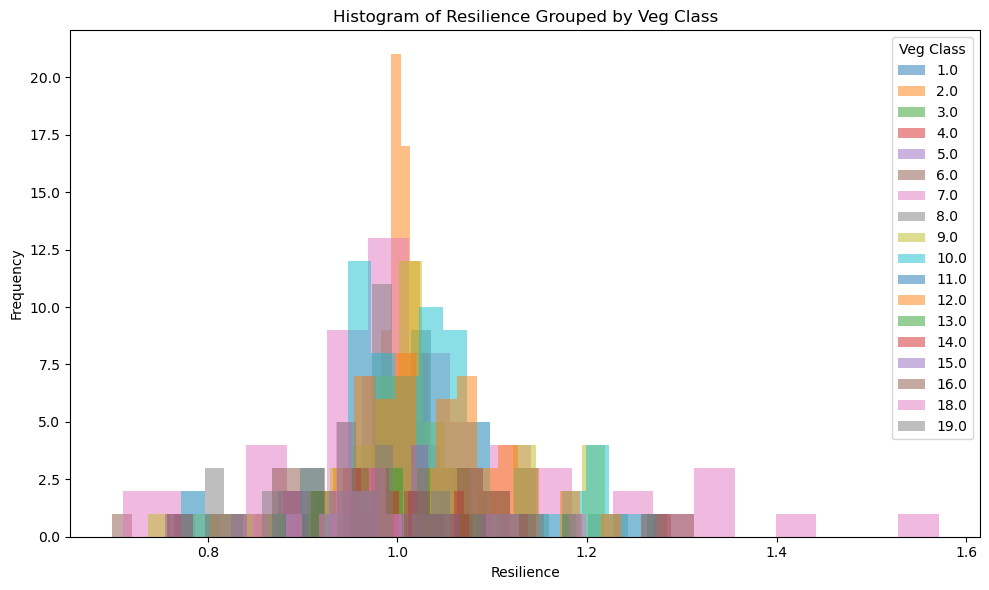

In [5]:
# Group by 'veg_class' level of the index
grouped = df_all.groupby(level='veg_class')['resilience']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, group in grouped:
    plt.hist(group.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Resilience')
plt.ylabel('Frequency')
plt.title('Histogram of Resilience Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

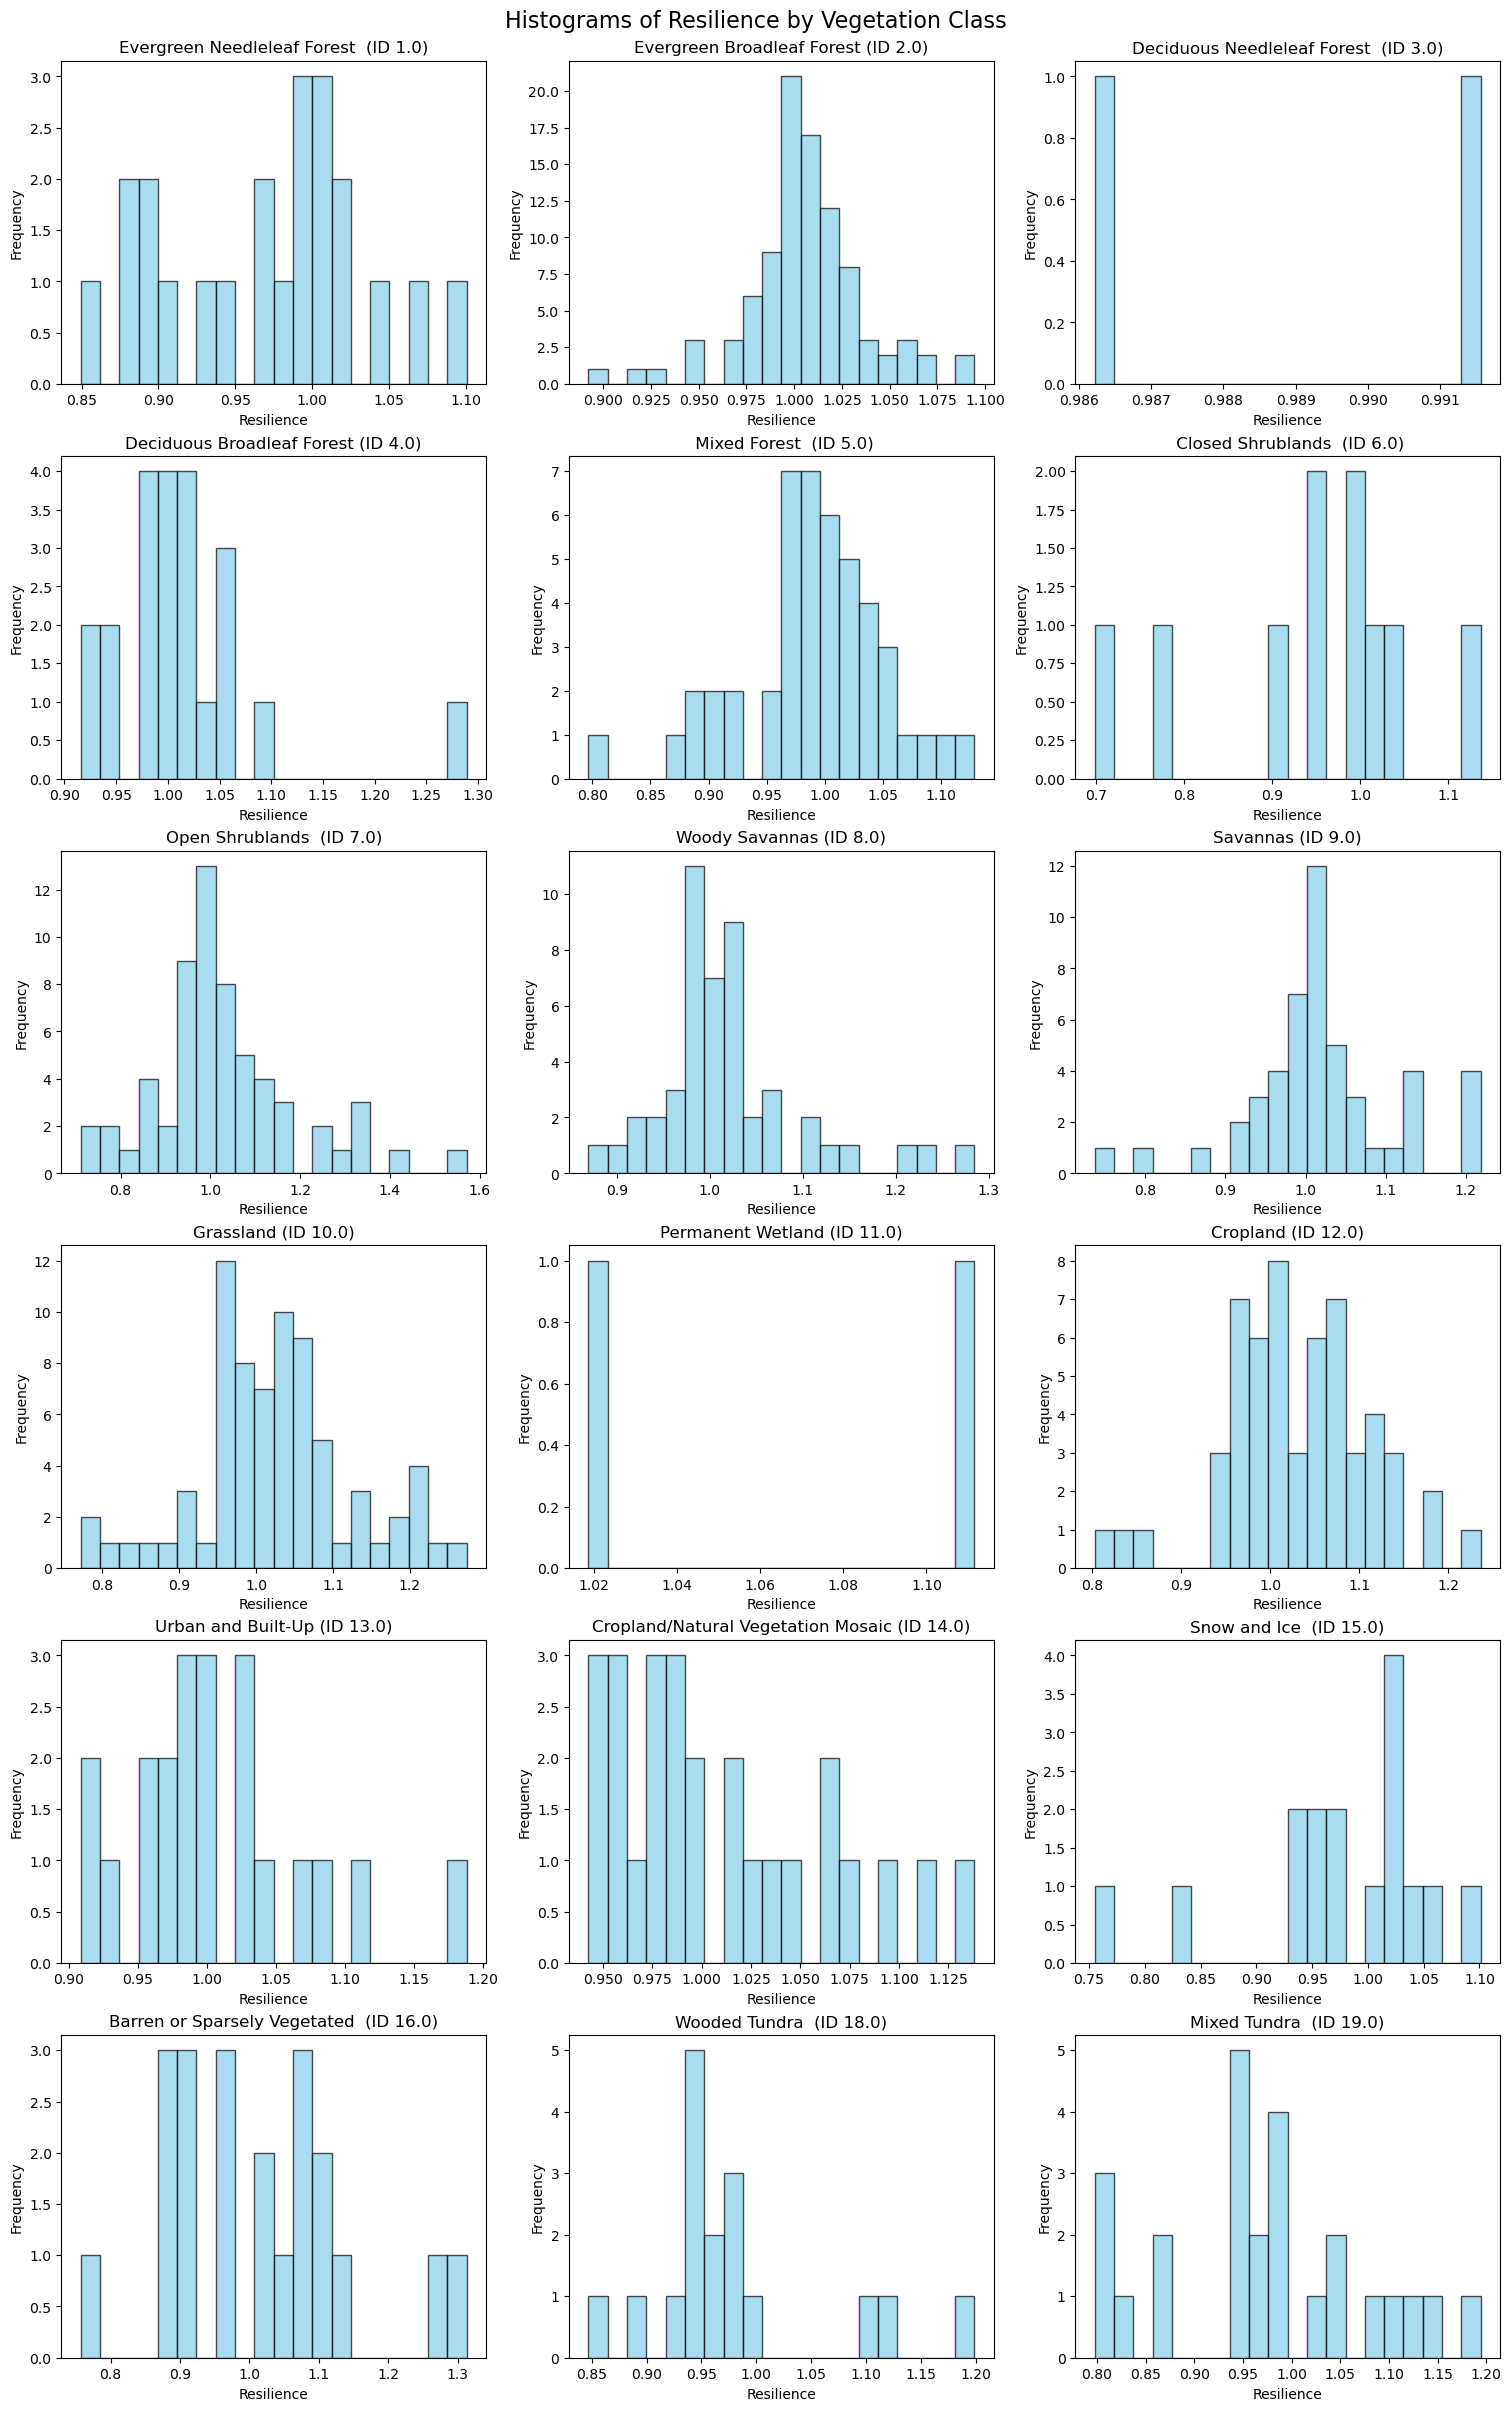

In [6]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Group df_all by 'veg_class' level in MultiIndex
grouped = df_all.groupby(level='veg_class')['resilience']

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Resilience')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Resilience by Vegetation Class', fontsize=16)
plt.show()

### Resistance

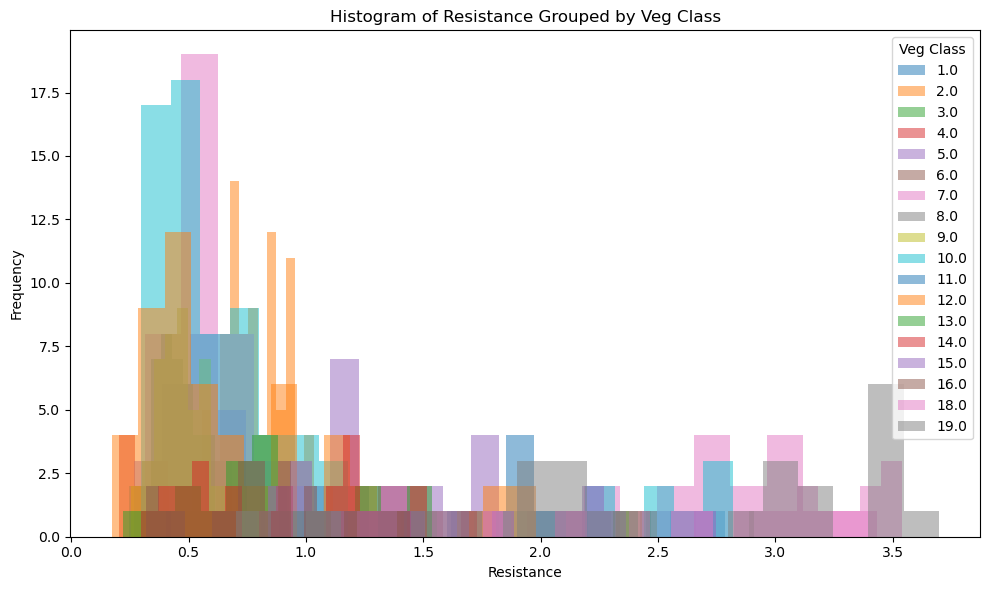

In [7]:
# Group by 'veg_class' level of the index
grouped_resist = df_all.groupby(level='veg_class')['resistance']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, group in grouped_resist:
    plt.hist(group.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Resistance')
plt.ylabel('Frequency')
plt.title('Histogram of Resistance Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

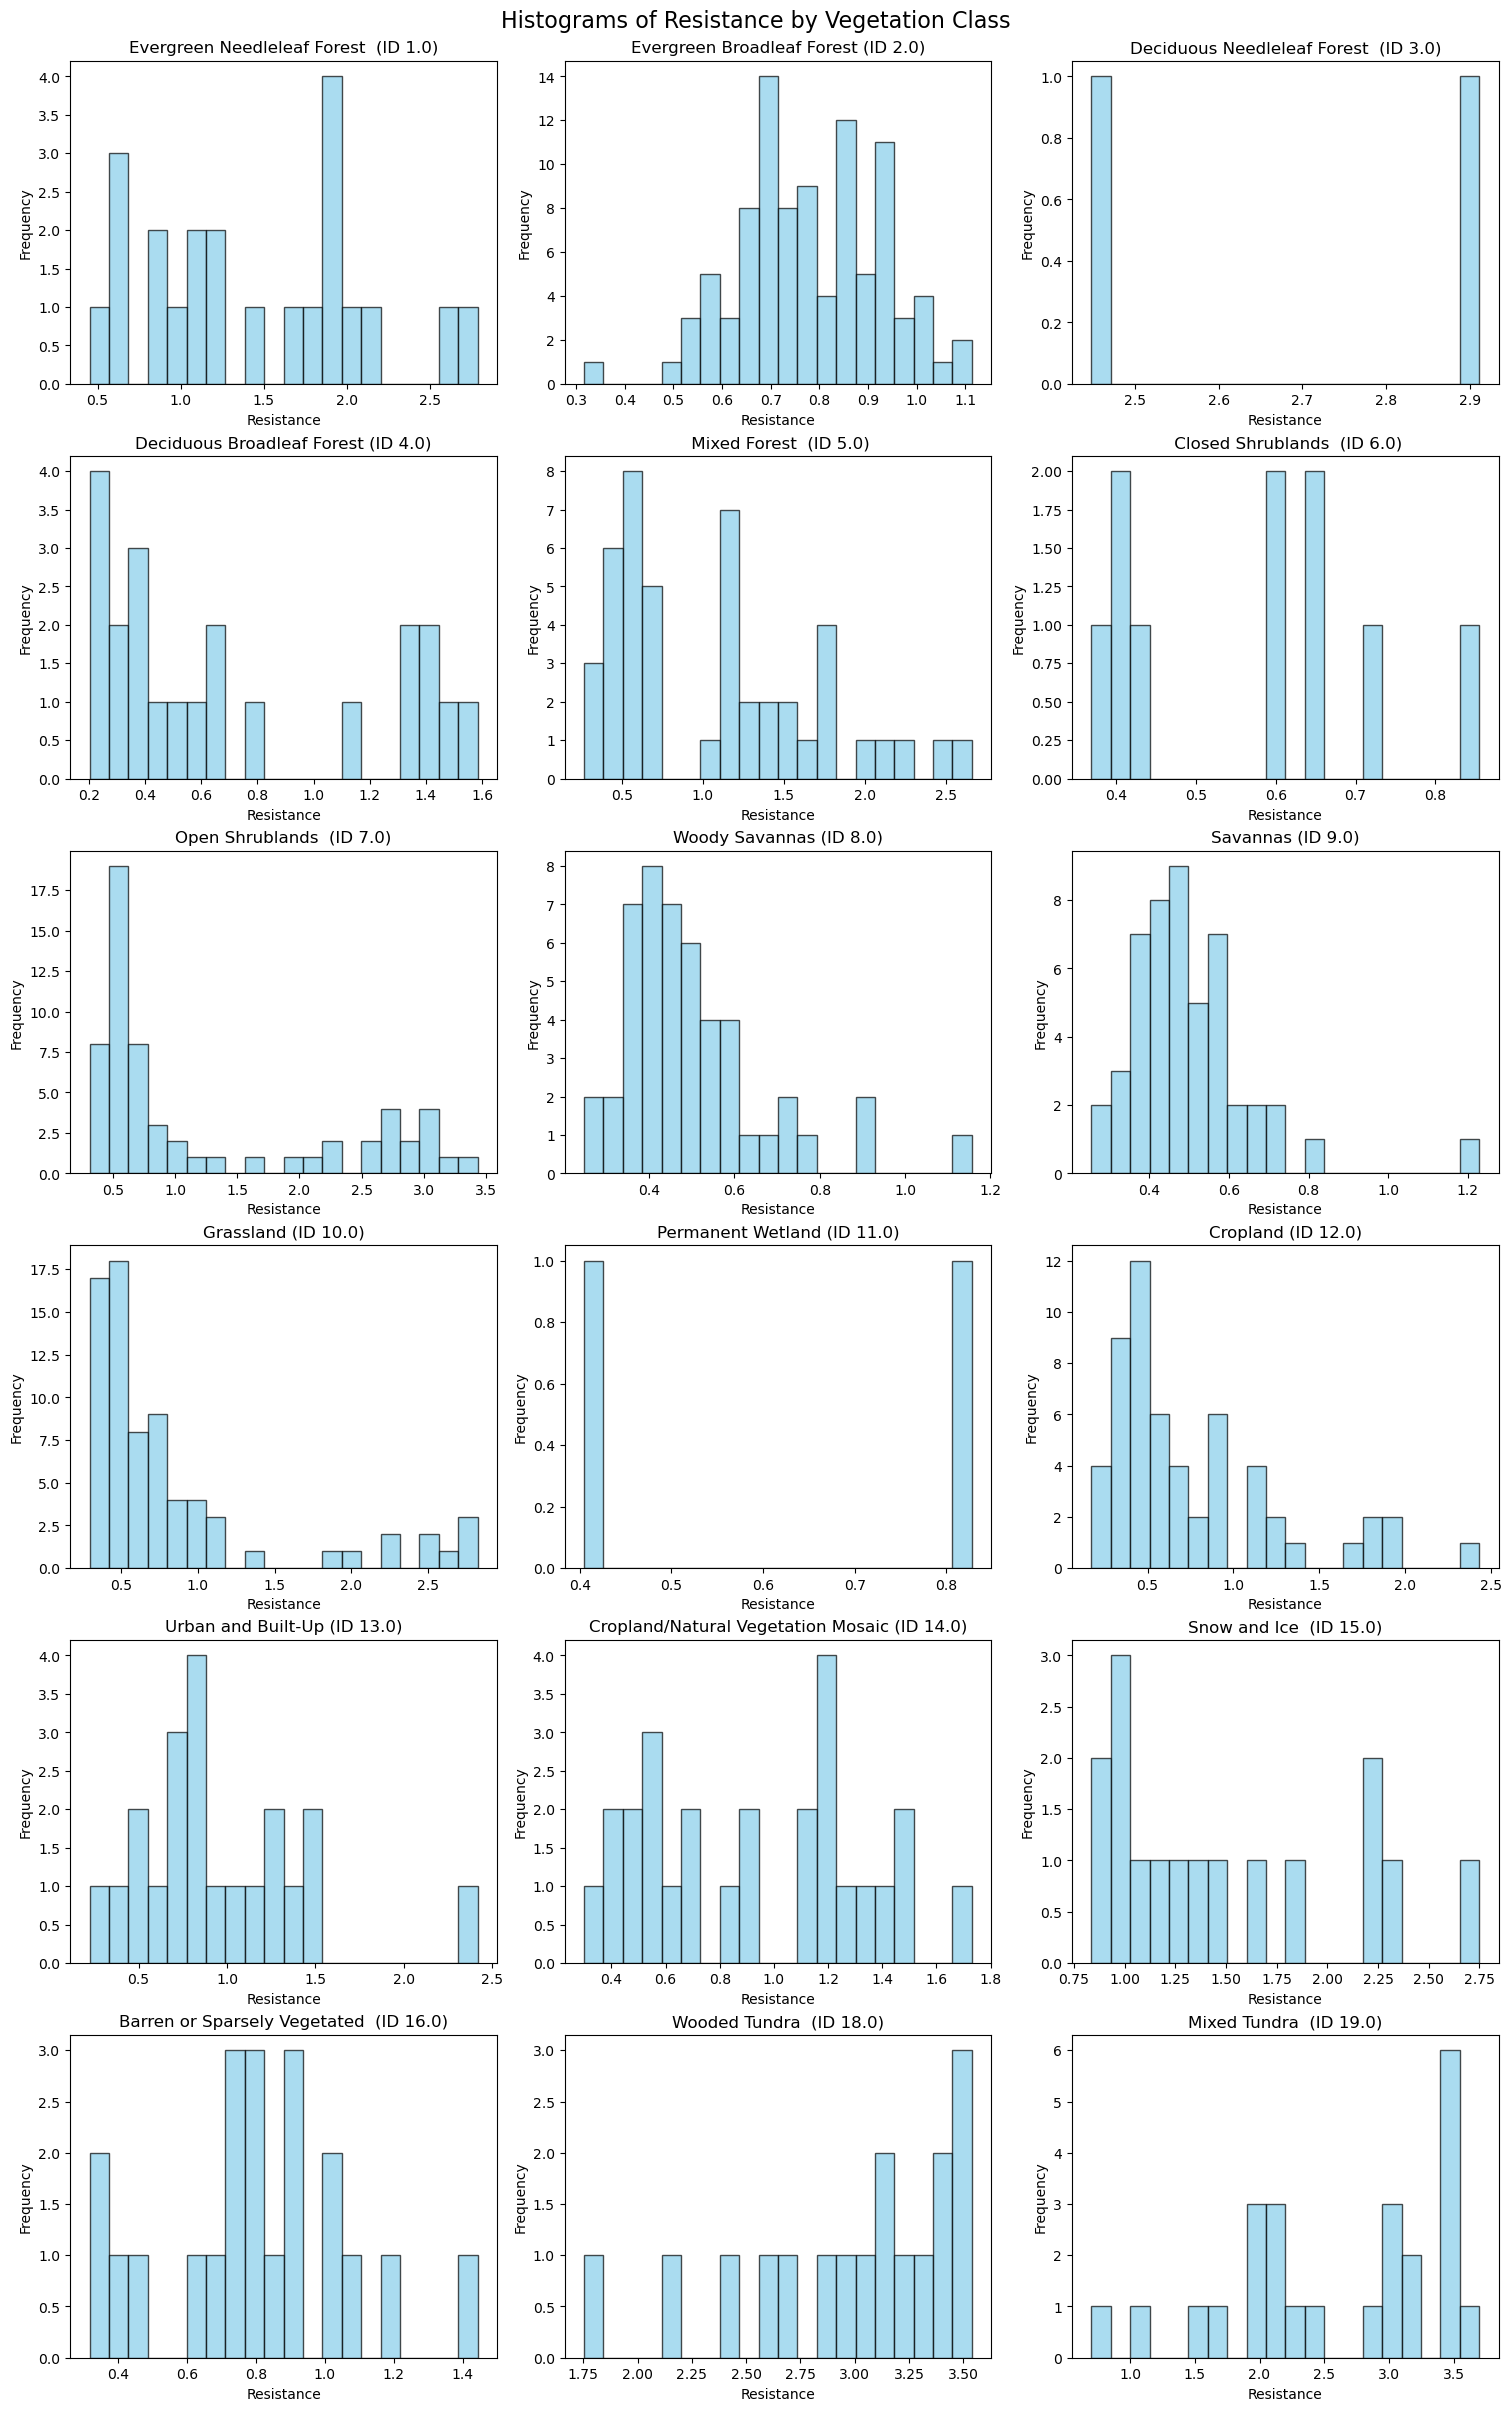

In [8]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Group df_all by 'veg_class' level in MultiIndex
grouped = df_all.groupby(level='veg_class')['resistance']

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Resistance')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Resistance by Vegetation Class', fontsize=16)
plt.show()

### Recovery

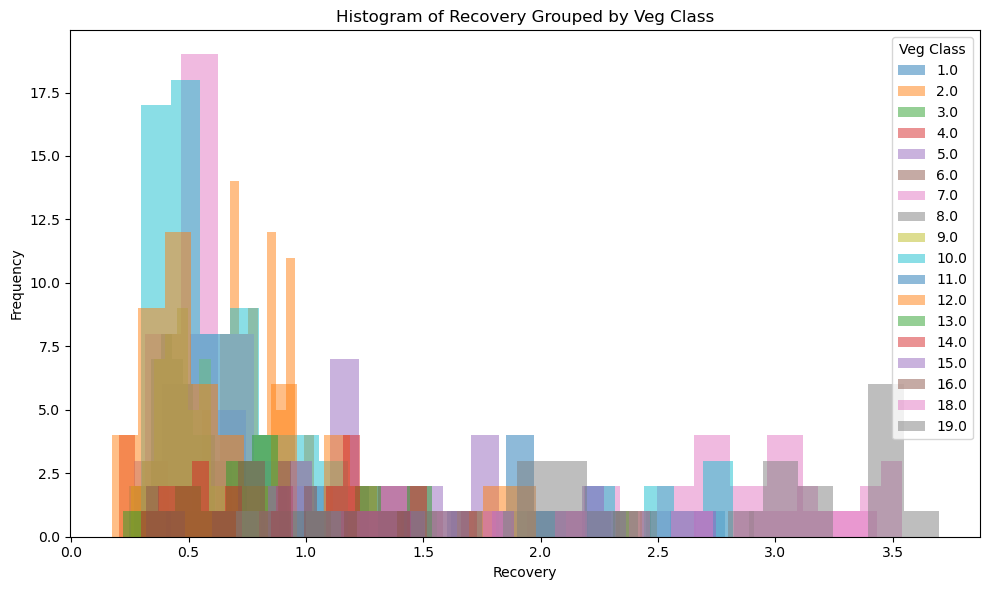

In [9]:
# Group by 'veg_class' level of the index
grouped_recov = df_all.groupby(level='veg_class')['recovery']

# Plot histograms for each group
plt.figure(figsize=(10, 6))

for name, grouped_recov in grouped:
    plt.hist(grouped_recov.dropna(), bins=20, alpha=0.5, label=str(name))  # dropna for clean histogram

plt.xlabel('Recovery')
plt.ylabel('Frequency')
plt.title('Histogram of Recovery Grouped by Veg Class')
plt.legend(title='Veg Class')
plt.tight_layout()
plt.show()

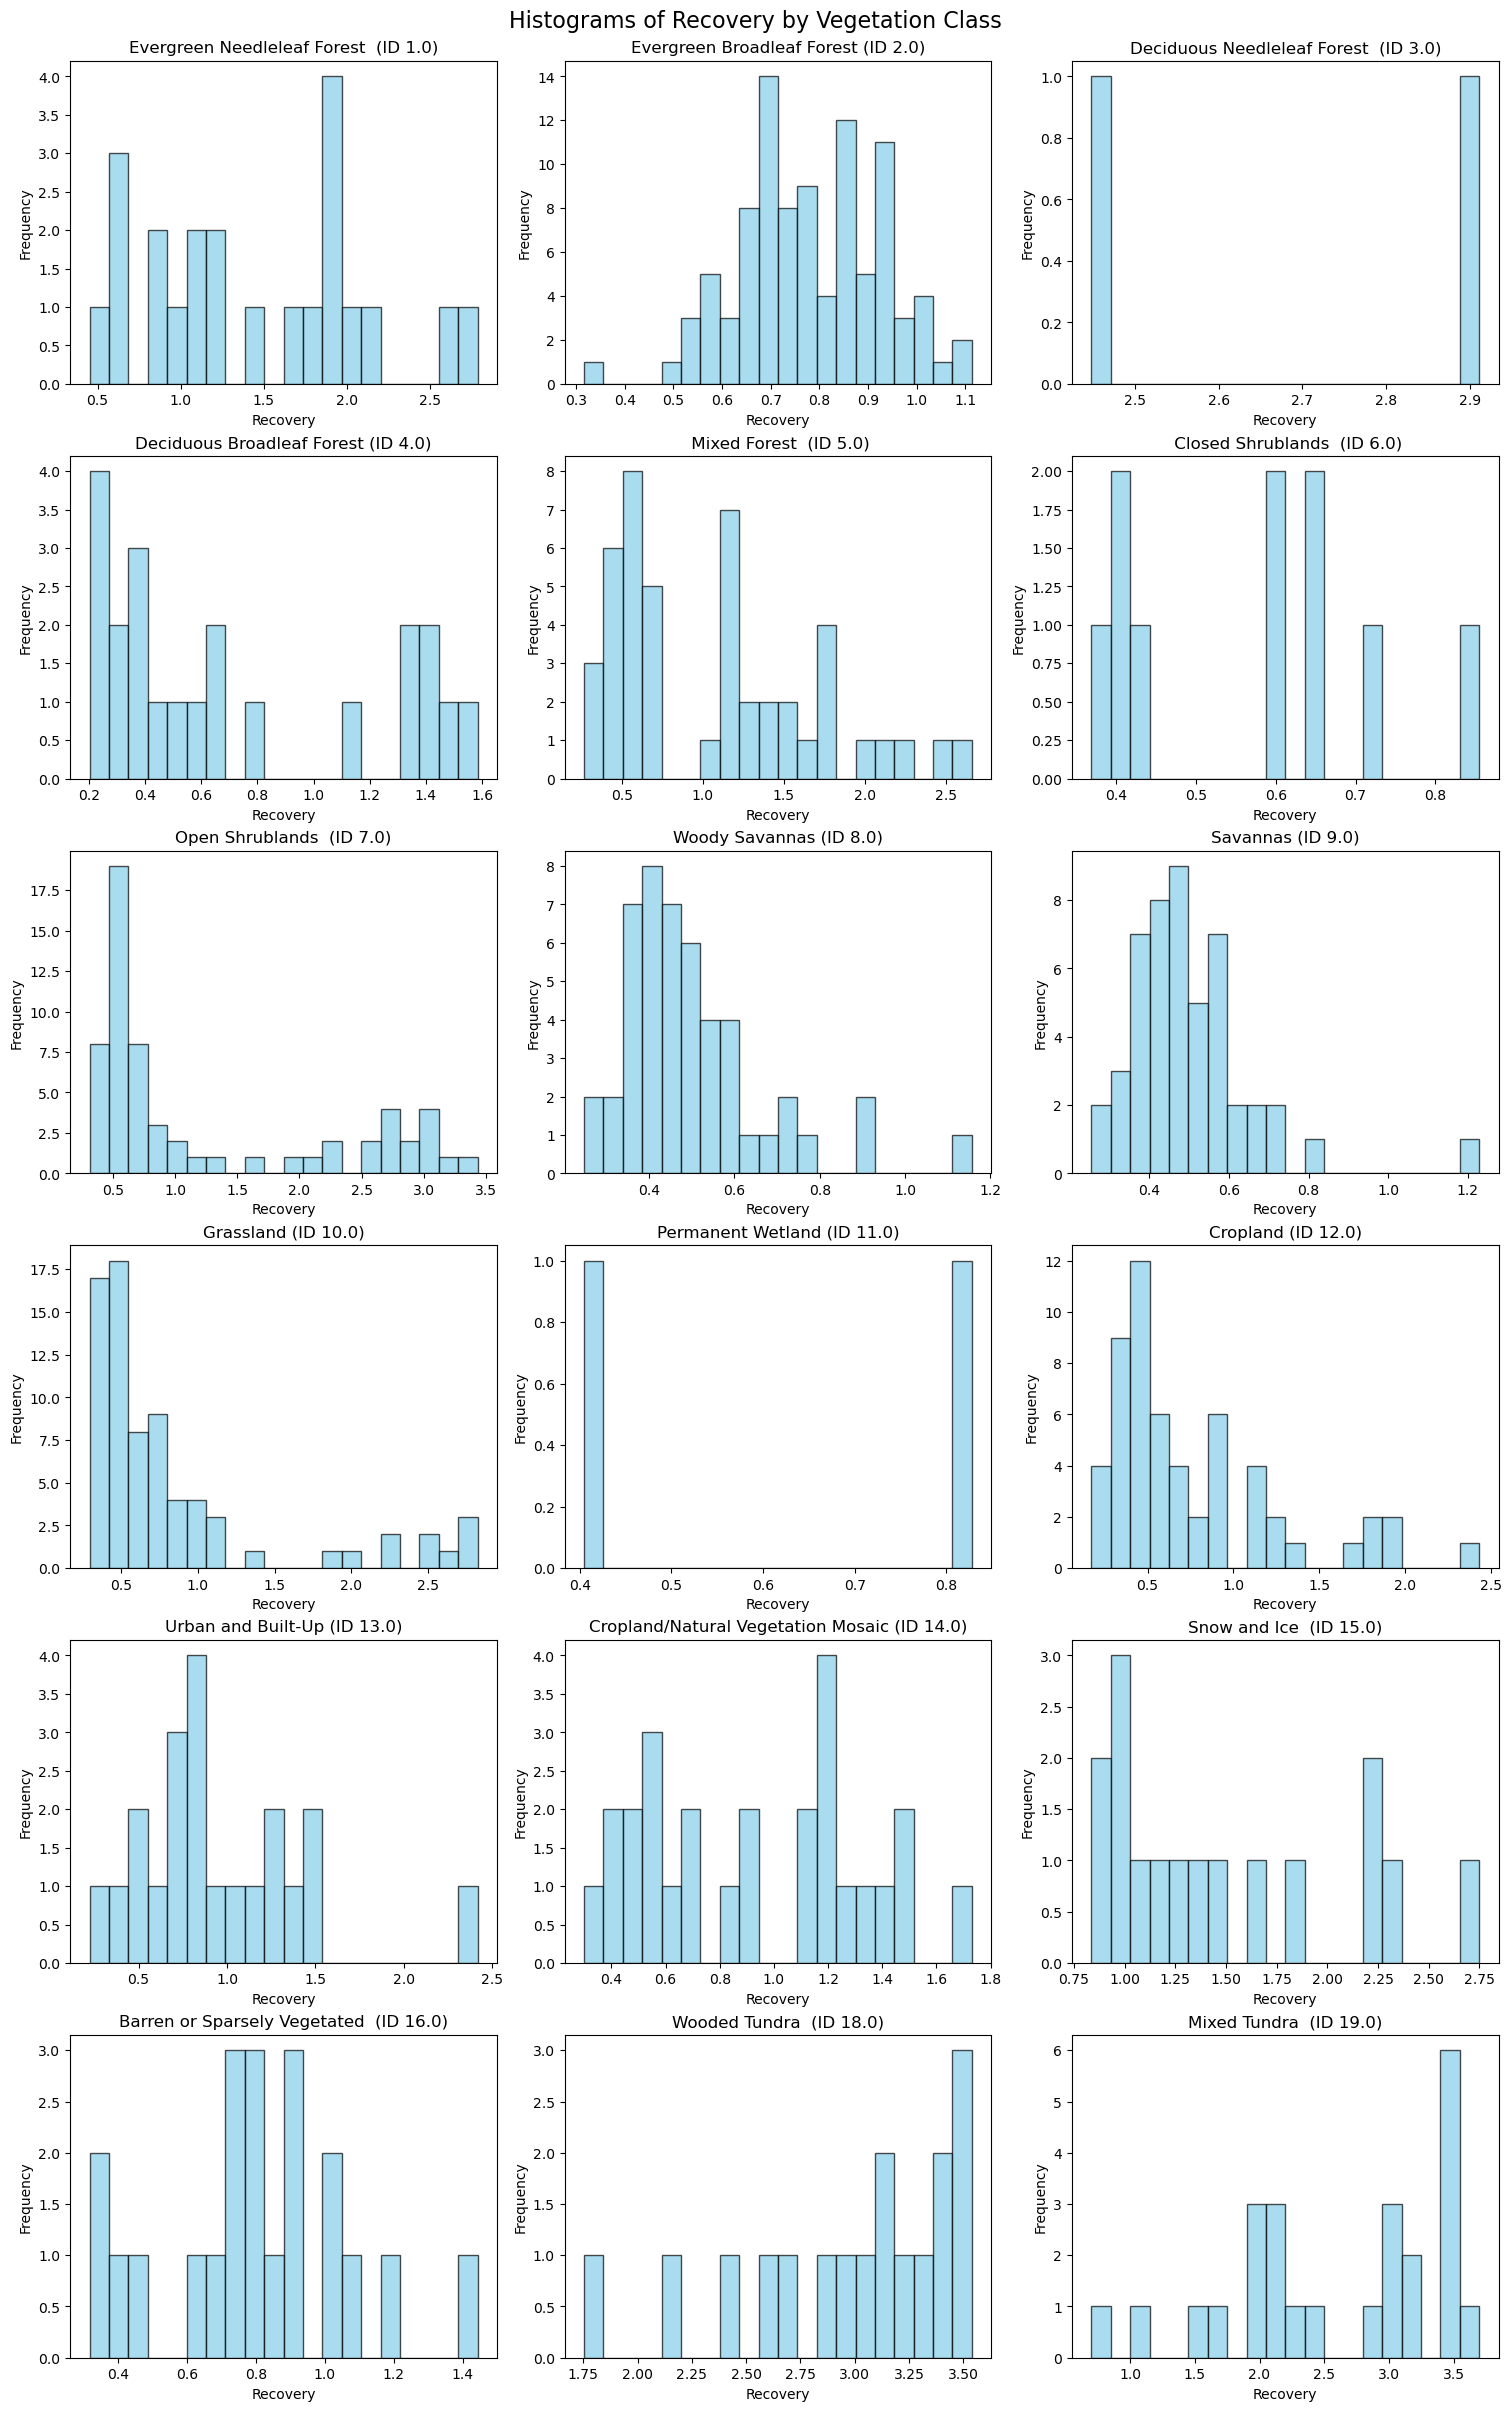

In [10]:
# Get mapping from numeric class to class name
class_name_map = df_translation.iloc[:, 0].to_dict()

# Get unique veg_classes and count for subplot grid
veg_classes = list(grouped.groups.keys())
n = len(veg_classes)

# Set up subplot grid (e.g., 3 columns)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Plot each veg_class in its own subplot with translated label
for i, veg_class in enumerate(veg_classes):
    class_name = class_name_map.get(veg_class, f'Class {veg_class}')  # fallback if not found
    group = grouped.get_group(veg_class)
    
    ax = axes[i]
    ax.hist(group.dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(f'{class_name} (ID {veg_class})')
    ax.set_xlabel('Recovery')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histograms of Recovery by Vegetation Class', fontsize=16)
plt.show()